#  Emotion Detection — Étape 4 : CNN + LSTM
**Idée :** le CNN extrait les features locales du spectrogramme, le LSTM modélise leur évolution dans le temps

---
##  Cellule 1 — Imports & Device

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.notebook import tqdm
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Device : {device}')
if torch.cuda.is_available():
    print(f'   GPU : {torch.cuda.get_device_name(0)}')

EMOTIONS  = ['angry','calm','disgust','fearful','happy','neutral','sad','surprised']
NUM_CLASS = len(EMOTIONS)
OUT       = '/kaggle/working'

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f' Seed fixée à {SEED}')

 Device : cuda
   GPU : Tesla T4
 Seed fixée à 42


---
##  Cellule 2 — Chargement & Normalisation

In [3]:
X_train = np.load(os.path.join(OUT, 'X_train.npy'))
y_train = np.load(os.path.join(OUT, 'y_train.npy'))
X_val   = np.load(os.path.join(OUT, 'X_val.npy'))
y_val   = np.load(os.path.join(OUT, 'y_val.npy'))
X_test  = np.load(os.path.join(OUT, 'X_test.npy'))
y_test  = np.load(os.path.join(OUT, 'y_test.npy'))

mean = X_train.mean()
std  = X_train.std()
X_train = (X_train - mean) / (std + 1e-8)
X_val   = (X_val   - mean) / (std + 1e-8)
X_test  = (X_test  - mean) / (std + 1e-8)

#  Ajout canal pour CNN
X_train = X_train[:, np.newaxis, :, :]  # (N, 1, 128, T)
X_val   = X_val[:,   np.newaxis, :, :]
X_test  = X_test[:,  np.newaxis, :, :]

print(f' X_train : {X_train.shape}')
print(f'   X_val   : {X_val.shape}')
print(f'   X_test  : {X_test.shape}')

 X_train : (3840, 1, 128, 126)
   X_val   : (240, 1, 128, 126)
   X_test  : (240, 1, 128, 126)


---
##  Cellule 3 — Class weights (correction déséquilibre)

In [4]:
label_counts = Counter(y_train.tolist())
total        = sum(label_counts.values())

weights = torch.tensor([
    total / (NUM_CLASS * label_counts[i])
    for i in range(NUM_CLASS)
], dtype=torch.float32).to(device)

print('Class weights :')
for emo, w in zip(EMOTIONS, weights):
    print(f'  {emo:<12} weight={w:.3f}')

Class weights :
  angry        weight=0.938
  calm         weight=0.938
  disgust      weight=0.938
  fearful      weight=0.938
  happy        weight=0.938
  neutral      weight=1.875
  sad          weight=0.938
  surprised    weight=0.938


---
##  Cellule 4 — SpecAugment

In [5]:
spec_augment = nn.Sequential(
    T.FrequencyMasking(freq_mask_param=20),
    T.FrequencyMasking(freq_mask_param=20),
    T.TimeMasking(time_mask_param=25),
    T.TimeMasking(time_mask_param=25),
).to(device)

print(' SpecAugment prêt (2×FreqMask + 2×TimeMask)')

 SpecAugment prêt (2×FreqMask + 2×TimeMask)


---
##  Cellule 5 — Dataset & DataLoaders

In [6]:
class SERDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 32

train_loader = DataLoader(SERDataset(X_train, y_train), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(SERDataset(X_val,   y_val),   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(SERDataset(X_test,  y_test),  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f' Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}')

 Train : 3840 | Val : 240 | Test : 240


---
## Cellule 6 — Architecture CNN + LSTM  ← NOUVEAU

```
Input (B, 1, 128, T)
       ↓
  CNN encoder          ← extrait des features locales (fréquence)
       ↓
  (B, 256, T')         ← séquence de vecteurs features dans le temps
       ↓
  BiLSTM (2 couches)   ← modélise la dynamique temporelle
       ↓
  Attention pooling    ← pondère les frames les plus informatives
       ↓
  Classifier → 8 classes
```

In [7]:
class AttentionPooling(nn.Module):
    """Pondère les frames temporelles selon leur importance."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x : (B, T, hidden_dim)
        scores  = self.attn(x).squeeze(-1)       # (B, T)
        weights = torch.softmax(scores, dim=-1)   # (B, T)
        return (x * weights.unsqueeze(-1)).sum(dim=1)  # (B, hidden_dim)


class EmotionCNNLSTM(nn.Module):
    """
    CNN encoder → BiLSTM → Attention pooling → Classifier
    Input  : (B, 1, 128, T)
    Output : (B, num_classes)
    """
    def __init__(self, num_classes=8, lstm_hidden=256, lstm_layers=2, dropout=0.3):
        super().__init__()

        # ── CNN encoder : réduit la dimension fréquence, garde le temps ──
        self.cnn = nn.Sequential(
            # Bloc 1 : (1, 128, T) → (32, 64, T)
            nn.Conv2d(1,  32, kernel_size=(3,3), padding=(1,1), bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2,1)),   # ← pool uniquement sur fréquence
            nn.Dropout2d(0.2),

            # Bloc 2 : (32, 64, T) → (64, 32, T)
            nn.Conv2d(32, 64, kernel_size=(3,3), padding=(1,1), bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2,1)),   # ← pool uniquement sur fréquence
            nn.Dropout2d(0.25),

            # Bloc 3 : (64, 32, T) → (128, 16, T)
            nn.Conv2d(64, 128, kernel_size=(3,3), padding=(1,1), bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2,1)),   # ← pool uniquement sur fréquence
            nn.Dropout2d(0.25),

            # Bloc 4 : (128, 16, T) → (256, 1, T)
            nn.Conv2d(128, 256, kernel_size=(3,3), padding=(1,1), bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, None)),   # ← collapse fréquence, garde temps
        )
        # Sortie CNN : (B, 256, 1, T) → reshape → (B, T, 256)

        # ── BiLSTM : modélise la dynamique temporelle ──
        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,       # ← BiLSTM : lit le signal dans les 2 sens
            dropout=dropout if lstm_layers > 1 else 0,
        )

        lstm_out_dim = lstm_hidden * 2  # × 2 car bidirectionnel

        # ── Attention pooling ──
        self.attention = AttentionPooling(lstm_out_dim)

        # ── Classifier ──
        self.classifier = nn.Sequential(
            nn.Linear(lstm_out_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # CNN
        x = self.cnn(x)              # (B, 256, 1, T)
        x = x.squeeze(2)             # (B, 256, T)
        x = x.permute(0, 2, 1)       # (B, T, 256) ← format LSTM

        # BiLSTM
        x, _ = self.lstm(x)          # (B, T, 512)

        # Attention pooling
        x = self.attention(x)        # (B, 512)

        # Classifier
        return self.classifier(x)    # (B, 8)


model = EmotionCNNLSTM(num_classes=NUM_CLASS).to(device)

# Test de la forme
with torch.no_grad():
    dummy = torch.zeros(2, 1, 128, X_train.shape[-1]).to(device)
    out   = model(dummy)
print(f'Modèle OK — input: {dummy.shape} → output: {out.shape}')

total = sum(p.numel() for p in model.parameters())
print(f'   Paramètres : {total:,}')

Modèle OK — input: torch.Size([2, 1, 128, 126]) → output: torch.Size([2, 8])
   Paramètres : 3,183,721


---
##  Cellule 7 — Configuration entraînement

In [8]:
EPOCHS   = 60
LR       = 5e-4   #  LR plus faible car LSTM est plus sensible
PATIENCE = 12

criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

print(f' Critère : CrossEntropyLoss + class weights + label_smoothing=0.1')
print(f'   Optim   : AdamW (lr={LR})')
print(f'   Epochs  : {EPOCHS} | Patience : {PATIENCE}')

 Critère : CrossEntropyLoss + class weights + label_smoothing=0.1
   Optim   : AdamW (lr=0.0005)
   Epochs  : 60 | Patience : 12


---
##  Cellule 8 — Boucle d'entraînement

In [9]:
history          = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss    = float('inf')
patience_counter = 0
best_model_path  = os.path.join(OUT, 'best_model_cnnlstm.pt')

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ──────────────────────────────────────────
    model.train()
    train_loss, train_correct = 0.0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        X_batch = spec_augment(X_batch)   # SpecAugment train seulement

        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss    += loss.item() * len(y_batch)
        train_correct += (out.argmax(1) == y_batch).sum().item()

    # ── VALIDATION ─────────────────────────────────────
    model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out  = model(X_batch)
            loss = criterion(out, y_batch)
            val_loss    += loss.item() * len(y_batch)
            val_correct += (out.argmax(1) == y_batch).sum().item()

    tl = train_loss    / len(X_train)
    ta = train_correct / len(X_train)
    vl = val_loss      / len(X_val)
    va = val_correct   / len(X_val)

    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['train_acc'].append(ta)
    history['val_acc'].append(va)

    scheduler.step()

    if vl < best_val_loss:
        best_val_loss    = vl
        patience_counter = 0
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'val_loss'   : vl,
            'val_acc'    : va,
        }, best_model_path)
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:02d}/{EPOCHS} | '
              f'Train {tl:.4f} / {ta:.2%} | '
              f'Val {vl:.4f} / {va:.2%} | '
              f'Patience {patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'\n  Early stopping à l\'epoch {epoch}')
        break

print(f'\n Terminé — meilleur val_loss : {best_val_loss:.4f}')

Epoch 01/60 | Train 2.0934 / 11.41% | Val 2.0923 / 13.33% | Patience 0/12
Epoch 05/60 | Train 2.0445 / 14.32% | Val 2.0465 / 11.67% | Patience 2/12
Epoch 10/60 | Train 2.0170 / 18.23% | Val 2.0398 / 20.83% | Patience 1/12
Epoch 15/60 | Train 2.0029 / 19.92% | Val 2.0227 / 22.50% | Patience 0/12
Epoch 20/60 | Train 1.8654 / 30.42% | Val 1.7501 / 35.83% | Patience 0/12
Epoch 25/60 | Train 1.7865 / 34.84% | Val 1.6940 / 40.00% | Patience 1/12
Epoch 30/60 | Train 1.7000 / 38.10% | Val 1.6678 / 40.00% | Patience 1/12
Epoch 35/60 | Train 1.6540 / 41.22% | Val 1.6582 / 40.00% | Patience 2/12
Epoch 40/60 | Train 1.6176 / 44.01% | Val 1.6373 / 39.58% | Patience 1/12
Epoch 45/60 | Train 1.5559 / 47.29% | Val 1.5957 / 43.33% | Patience 6/12
Epoch 50/60 | Train 1.5435 / 47.37% | Val 1.6286 / 41.25% | Patience 11/12

  Early stopping à l'epoch 51

 Terminé — meilleur val_loss : 1.5801


---
##  Cellule 9 — Courbes d'apprentissage

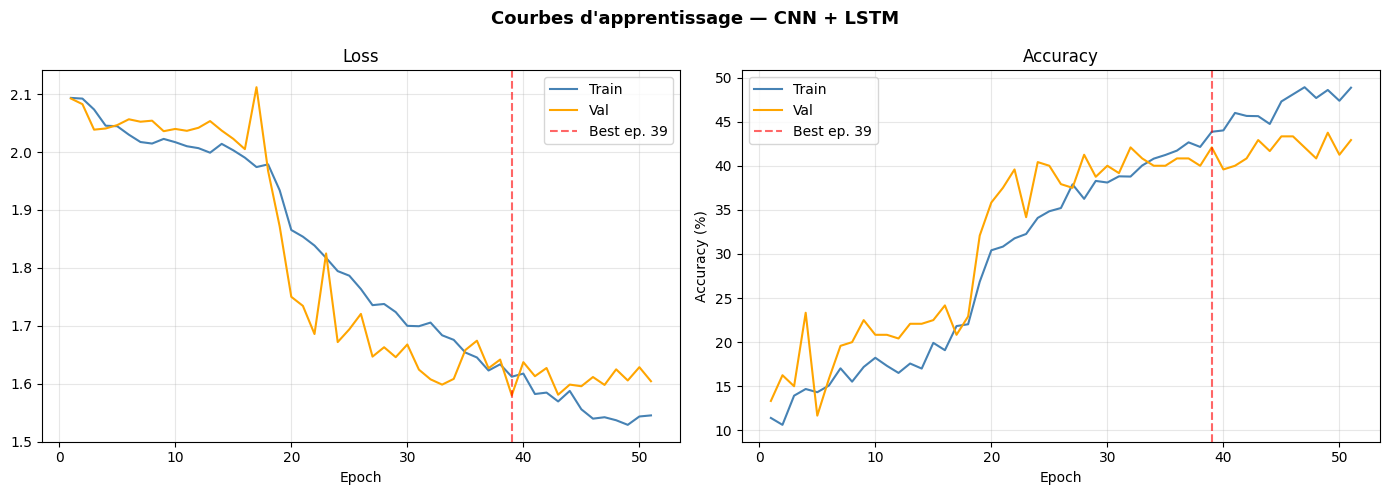

Best epoch : 39 | Best val acc : 43.75%


In [10]:
epochs_range = range(1, len(history['train_loss']) + 1)
best_ep      = np.argmin(history['val_loss']) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Courbes d\'apprentissage — CNN + LSTM', fontsize=13, fontweight='bold')

axes[0].plot(epochs_range, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='orange')
axes[0].axvline(best_ep, color='red', linestyle='--', alpha=0.6, label=f'Best ep. {best_ep}')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], label='Train', color='steelblue')
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val',   color='orange')
axes[1].axvline(best_ep, color='red', linestyle='--', alpha=0.6, label=f'Best ep. {best_ep}')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'courbes_cnnlstm.png'), bbox_inches='tight')
plt.show()
print(f'Best epoch : {best_ep} | Best val acc : {max(history["val_acc"]):.2%}')

---
##  Cellule 10 — Évaluation Test + Comparaison

In [11]:
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f' Meilleur modèle chargé (epoch {checkpoint["epoch"]} | val_acc {checkpoint["val_acc"]:.2%})')

model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)
test_acc  = (all_preds == all_true).mean()

print(f'\n=== Résultats Test Set ===')
print(f'Accuracy : {test_acc:.2%}')
print()
print(classification_report(all_true, all_preds, target_names=EMOTIONS,
                             digits=3, zero_division=0))

# Comparaison avec les modèles précédents
print('=' * 45)
print(f'  CNN de base        : 50.83%')
print(f'  CNN + SpecAugment  : 52.50%')
print(f'  CNN + LSTM         : {test_acc:.2%}  ← actuel')
print('=' * 45)

 Meilleur modèle chargé (epoch 39 | val_acc 42.08%)

=== Résultats Test Set ===
Accuracy : 40.00%

              precision    recall  f1-score   support

       angry      0.310     0.406     0.351        32
        calm      0.510     0.781     0.617        32
     disgust      0.368     0.875     0.519        32
     fearful      0.417     0.156     0.227        32
       happy      0.238     0.156     0.189        32
     neutral      0.529     0.562     0.545        16
         sad      0.400     0.062     0.108        32
   surprised      0.500     0.281     0.360        32

    accuracy                          0.400       240
   macro avg      0.409     0.410     0.365       240
weighted avg      0.401     0.400     0.353       240

  CNN de base        : 50.83%
  CNN + SpecAugment  : 52.50%
  CNN + LSTM         : 40.00%  ← actuel


---
##  Cellule 11 — Matrice de confusion + UAR

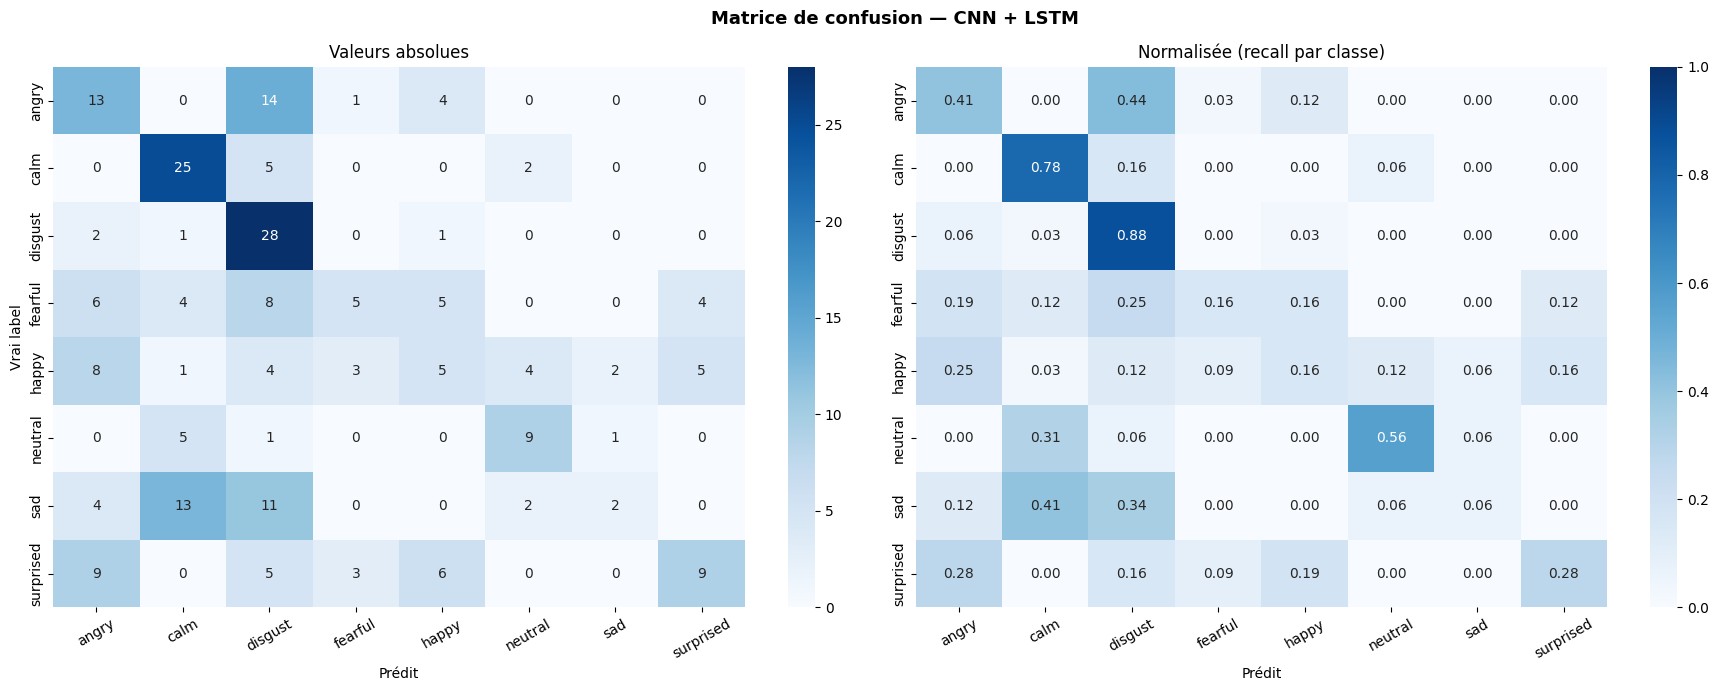


 UAR : 41.02% | Accuracy : 40.00%

  angry        40.62%  ████████
  calm         78.12%  ███████████████
  disgust      87.50%  █████████████████
  fearful      15.62%  ███
  happy        15.62%  ███
  neutral      56.25%  ███████████
  sad          6.25%  █
  surprised    28.12%  █████


In [13]:
cm      = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matrice de confusion — CNN + LSTM', fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[0])
axes[0].set_title('Valeurs absolues')
axes[0].set_ylabel('Vrai label')
axes[0].set_xlabel('Prédit')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Normalisée (recall par classe)')
axes[1].set_ylabel('')
axes[1].set_xlabel('Prédit')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'confusion_cnnlstm.png'), bbox_inches='tight')
plt.show()

recalls = cm.diagonal() / cm.sum(axis=1)
uar     = recalls.mean()

print(f'\n UAR : {uar:.2%} | Accuracy : {test_acc:.2%}')
print()
for emo, rec in zip(EMOTIONS, recalls):
    bar = '█' * int(rec * 20)
    print(f'  {emo:<12} {rec:.2%}  {bar}')